## Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic

Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn

1. Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [27]:
pip install scikit-learn pandas numpy matplotlib graphviz

Note: you may need to restart the kernel to use updated packages.


In [28]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

2. Nạp dữ liệu, phân tích và loại bỏ features không cần thiết

In [29]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
features_response = df.columns.tolist()
print(features_response)

# Các cột cần loại bỏ
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


3. Xử lý dữ liệu (biến đổi và làm sạch)

In [31]:
df.isnull().sum()


Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [32]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [33]:
#diền trung vị cho Age 
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# mã hóa giới tính 
df['Sex']= df['Sex'].map({'male': 0, 'female': 1})
# mã hóa Embarked
df['Embarked'] = df['Embarked'].map({'S':2, 'C':0, 'Q':1})

df.head()
df.isna().sum()
df.isnull().sum()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19796\706223971.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19796\706223971.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

4️. Tách dữ liệu train/test

In [35]:
from sklearn.model_selection import train_test_split
from sklearn import tree

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


5. Xây dựng cây quyết định

In [36]:
decision_tree = tree.DecisionTreeClassifier(max_depth=2, random_state=42)
decision_tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=2, random_state=42)

6. Vẽ cây 

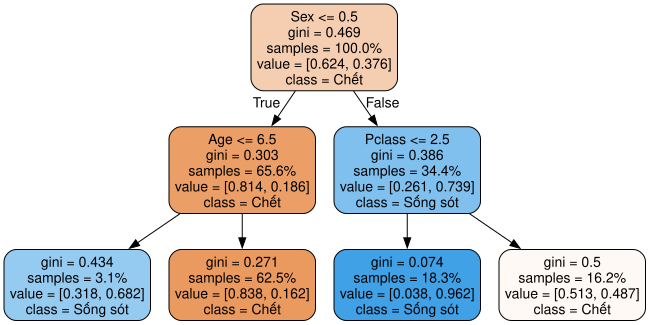

In [42]:
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz\bin'
dot_data = tree.export_graphviz(
    decision_tree,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=X_train.columns,
    proportion=True,
    class_names=['Chết', 'Sống sót']
)

graph = graphviz.Source(dot_data)
graph


7. Dánh giá mô hình 

In [44]:
from sklearn.metrics import accuracy_score

y_predict = decision_tree.predict(X_test)
print("Độ chính xác trên tập test:", accuracy_score(y_test, y_predict))


Độ chính xác trên tập test: 0.7653631284916201
